In [1]:
import pandas as pd
import json
import numpy as np
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, r2_score
from sklearn.metrics import classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
%config IPCompleter.greedy = True
import matplotlib.pyplot as plt
%matplotlib inline

# Задание

Скачайте данные об отзывах клиентов банков https://disk.yandex.ru/d/2o1ZmkzBQMANqw.

In [2]:
df = pd.read_csv('reviews_banks.csv')

In [3]:
df.head(10)

,bank,feeds,grades,date
0,ubrr,"Много лет являюсь клиентом этого банка, но пос...",1.0,16.02.2017 16:10
1,fk_otkritie,"Г. Ростов-на-Дону, ул. Ленина, 48. Были 10.12....",2.0,13.12.2016 1:05
2,alfabank,Здравствуйте!Ранее уже оставлял отзыв о вашем ...,NaN,28.06.2019 13:54
3,vtb,Обращаюсь к Вам с жалобой на незаконное списан...,NaN,15.07.2020 14:54
4,promsvyazbank,"Имею потребительский кредит, взятый в Связь-ба...",2.0,04.08.2020 6:38
5,pochtabank,Брала кредит на стиральную машину. Все платила...,NaN,09.04.2015 17:19
6,otpbank,"Откуда взялся долг по кредитной карте, если я ...",NaN,28.01.2021 13:20
7,homecreditbank,Хочу выразить глубокую благодарность всем сотр...,5.0,19.04.2015 20:11
8,vtb,"6 марта 2019г. В 10:33 при проходе в метро ""Ку...",2.0,28.03.2019 18:36
9,fk_otkritie,"Уважаемый Бинбанк, если у вас имеются какие-ли...",NaN,31.08.2018 16:48


In [4]:
df.shape

(75000, 4)

## Задание

Удалите из таблицы df строки, где целевая переменная grades неизвестна.

In [5]:
df = df.dropna(subset=['grades'])

In [6]:
df.shape

(51476, 4)

Постройте гистограмму распределения для столбца grades.

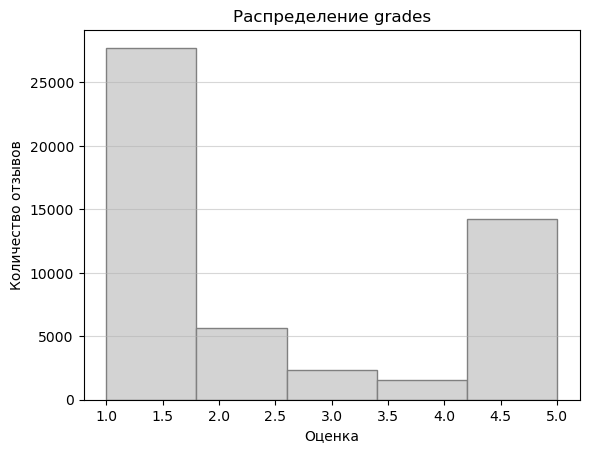

In [7]:
plt.hist(df['grades'], bins=5, color='lightgrey', edgecolor='grey')
plt.title('Распределение grades')
plt.xlabel('Оценка')
plt.ylabel('Количество отзывов')
plt.grid(axis='y', alpha=0.5)
plt.show()

## Задание

Для каждого банка (bank) вычислите средний grade.

Отсортируйте результаты в порядке убывания этого среднего.

In [8]:
bank_ratings = (
    df.groupby('bank')['grades']
    .mean()
    .sort_values(ascending=False)
)

bank_ratings

bank
interprombank     4.584000
modulbank         4.060071
talkbank          4.050000
tochka            4.000000
nordea            3.733333
                    ...   
rncb              1.533333
v-express-bank    1.477679
atb               1.415730
bnpparibasbank    1.333333
roundbank         1.156863
Name: grades, Length: 69, dtype: float64

## Задание

При помощи TfidfVectorizer с гиперпараметрами
`min_df=5, max_df=1.0, ngram_range=(1, 1)`
закодируйте столбец `feeds`.

Преобразованный столбец сохраните в переменную `descr`.

In [9]:
tfidf = TfidfVectorizer(min_df=5, max_df=1.0, ngram_range=(1, 1))
descr = tfidf.fit_transform(df['feeds'])

In [10]:
descr.shape

(51476, 45602)

## Задание

При помощи `train_test_split` разбейте данные на тренировочную и тестовую части:

* в качестве матрицы признаков используйте закодированные отзывы `descr`

* вектор ответов - `df['grades']`

В тест отправьте 20% данных, зафиксируйте `random_state=42`.

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    descr, 
    df['grades'], 
    test_size=0.2, 
    random_state=42
)

## Задание

Будем решать задачу прогноза grades как задачу регрессии.

Обучите [Ridge-регрессию](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html) (с гиперпараметрами по умолчанию) на тренировочных данных и выведите качество модели ($R^2$) на трейне и на тесте.

In [25]:
clf = Ridge()
clf.fit(X_train, y_train)

y_train_pred = clf.predict(X_train)
y_test_pred = clf.predict(X_test)

print(f"R² на трейне: {r2_score(y_train, y_train_pred):.4f}")
print(f"R² на тесте: {r2_score(y_test, y_test_pred):.4f}")

R² на трейне: 0.8531
R² на тесте: 0.7289


Посмотрим как работает ваша модель.

In [19]:
clf.predict(tfidf.transform(["Отличный банк! Очень нравится!"]))

array([5.61127242])

In [20]:
clf.predict(tfidf.transform(["Отвратительное обслуживание, я разочарована."]))

array([0.66948052])

## Задание

Выведите на экран в виде pd.DataFrame топ-10 признаков с наибольшим положительным весом, а затем топ-10 признаков с наибольшим отрицательным весом.

In [21]:
feature_names = tfidf.get_feature_names_out()

coefs = pd.DataFrame({
    'feature': feature_names,
    'weight': clf.coef_
})

coefs = coefs.sort_values(by='weight', ascending=False)

In [23]:
coefs.head(10)

,feature,weight
39042,спасибо,5.398713
3800,благодарность,4.016548
32396,приятно,3.567098
27407,поблагодарить,3.484219
9546,доволен,3.272972
3810,благодарю,3.142123
3792,благодарен,3.108239
17238,лучший,2.894784
4352,быстро,2.872336
29385,понравилось,2.828097


In [24]:
coefs.tail(10)[::-1]

,feature,weight
20117,не,-2.511210
24508,отвратительное,-2.352232
22165,обман,-2.316021
21601,никому,-2.139465
24513,отвратительный,-2.003499
42310,ужасное,-1.897412
11796,закрою,-1.888950
27439,поведение,-1.776028
24709,отказано,-1.770192
41412,требую,-1.763249


## Бонус

Поэкспериментируйте с настройками:

* можно настраивать гиперпараметры в Tf-Idf кодировщике (или попробовать CountVectorizer)

* можно настраивать (при помощи GridSearchCV) гиперпараметр регуляризации `C` у Ridge-регрессии (или попробовать Lasso-регрессию).

Ваша цель - добиться наилучшего качества $R^2$ на тестовых данных.

In [27]:
from sklearn.pipeline import Pipeline

model_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(min_df=5, max_df=0.9)),
    ('ridge', Ridge())
])

param_grid = {
    'tfidf__ngram_range': [(1, 1), (1, 2)], 
    'tfidf__use_idf': [True, False],
    'ridge__alpha': [0.1, 1.0, 10.0, 100.0]
}

grid_search = GridSearchCV(model_pipeline, param_grid, cv=3, scoring='r2', n_jobs=-1, verbose=1)
grid_search.fit(df['feeds'], df['grades'])

print(f"Лучшие параметры: {grid_search.best_params_}")
print(f"Лучший R² на кросс-валидации: {grid_search.best_score_:.4f}")

Fitting 3 folds for each of 16 candidates, totalling 48 fits
Лучшие параметры: {'ridge__alpha': 1.0, 'tfidf__ngram_range': (1, 2), 'tfidf__use_idf': True}
Лучший R² на кросс-валидации: 0.7444
